# Interval Domain Demo

## Table of Contents

1. [Basic Domain Creation and Properties](#1-basic-domain-creation-and-properties)
2. [Domain Membership Testing](#2-domain-membership-testing)
3. [Topological Operations](#3-topological-operations)
4. [Mesh Generation](#4-mesh-generation)
5. [Integration Capabilities](#5-integration-capabilities)
6. [Integration over Multiple Support Regions](#6-integration-over-multiple-support-regions)
7. [Domain Restrictions and Subintervals](#7-domain-restrictions-and-subintervals)
8. [Splitting Domains at Discontinuities](#8-splitting-domains-at-discontinuities)
9. [Vectorized vs Non-Vectorized Functions](#9-vectorized-vs-non-vectorized-functions)
10. [Summary](#10-summary)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Import from the intervalinf package
from intervalinf import IntervalDomain

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Basic Domain Creation and Properties

Let's start by creating different types of interval domains and exploring their properties.

In [2]:
# Create different types of interval domains
closed_interval = IntervalDomain(0, 1, boundary_type='closed', name="Unit Interval")
open_interval = IntervalDomain(0, 1, boundary_type='open', name="Open Unit Interval")
left_open = IntervalDomain(-1, 2, boundary_type='left_open', name="Left-Open Interval")
right_open = IntervalDomain(-1, 2, boundary_type='right_open', name="Right-Open Interval")

domains = [closed_interval, open_interval, left_open, right_open]

print("Domain Types and Representations:")
print("="*50)
for domain in domains:
    print(f"{domain.name:20s}: {domain}")
    print(f"{'':20s}  Length: {domain.length:.3f}")
    print(f"{'':20s}  Center: {domain.center:.3f}")
    print(f"{'':20s}  Radius: {domain.radius:.3f}")
    print()

Domain Types and Representations:
Unit Interval       : [0.0, 1.0]
                      Length: 1.000
                      Center: 0.500
                      Radius: 0.500

Open Unit Interval  : (0.0, 1.0)
                      Length: 1.000
                      Center: 0.500
                      Radius: 0.500

Left-Open Interval  : (-1.0, 2.0]
                      Length: 3.000
                      Center: 0.500
                      Radius: 1.500

Right-Open Interval : [-1.0, 2.0)
                      Length: 3.000
                      Center: 0.500
                      Radius: 1.500



## 2. Domain Membership Testing

Test how different boundary types affect point membership.

### Core API Usage:

In [3]:
# Core API: Test membership for single points and arrays
unit_domain = IntervalDomain(0, 1, boundary_type='closed')

# Single point
unit_domain.contains(0.5)  # Returns True

# Array of points
test_points = np.array([-0.5, 0.0, 0.5, 1.0, 1.5])
unit_domain.contains(test_points)  # Returns boolean array

array([False,  True,  True,  True, False])

Domain Membership Test:
 Point |    [0,1] |    (0,1) |   (-1,2] |   [-1,2)
------------------------------------------------------------
  -0.5 |    False |    False |     True |     True
   0.0 |     True |    False |     True |     True
   0.5 |     True |     True |     True |     True
   1.0 |     True |    False |     True |     True
   1.5 |    False |    False |     True |     True

Array Membership Test:


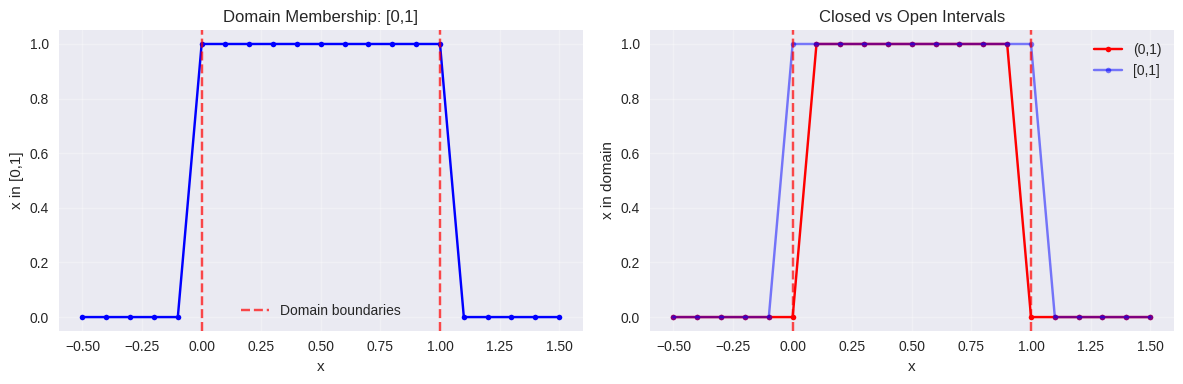

In [4]:
# Test points including boundary points
test_points = np.array([-0.5, 0.0, 0.5, 1.0, 1.5])

print("Domain Membership Test:")
print("="*60)
print(f"{'Point':>6s} | {'[0,1]':>8s} | {'(0,1)':>8s} | {'(-1,2]':>8s} | {'[-1,2)':>8s}")
print("-"*60)

for x in test_points:
    memberships = [domain.contains(x) for domain in domains]
    print(f"{x:6.1f} | {str(memberships[0]):>8s} | {str(memberships[1]):>8s} | {str(memberships[2]):>8s} | {str(memberships[3]):>8s}")

# Test with arrays
print("\nArray Membership Test:")
unit_domain = IntervalDomain(0, 1, boundary_type='closed')
x_array = np.linspace(-0.5, 1.5, 21)
in_domain = unit_domain.contains(x_array)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x_array, in_domain, 'bo-', markersize=4)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Domain boundaries')
plt.axvline(1, color='red', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('x in [0,1]')
plt.title('Domain Membership: [0,1]')
plt.grid(True, alpha=0.3)
plt.legend()

# Compare with open interval
open_unit = IntervalDomain(0, 1, boundary_type='open')
in_open = open_unit.contains(x_array)

plt.subplot(1, 2, 2)
plt.plot(x_array, in_open, 'ro-', markersize=4, label='(0,1)')
plt.plot(x_array, in_domain, 'bo-', markersize=4, alpha=0.5, label='[0,1]')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.axvline(1, color='red', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('x in domain')
plt.title('Closed vs Open Intervals')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Detailed Examples and Visualization:

## 3. Topological Operations

Demonstrate interior, closure, and boundary point operations.

In [5]:
# Start with a general interval
original = IntervalDomain(-1, 2, boundary_type='closed', name="Original")

# Get topological variants
interior = original.interior()
closure = original.closure()
boundary_pts = original.boundary_points()

print("Topological Operations:")
print("="*40)
print(f"Original domain:  {original}")
print(f"Interior:         {interior}")
print(f"Closure:          {closure}")
print(f"Boundary points:  {boundary_pts}")

# Test with different starting types
print("\nStarting from different boundary types:")
for bt in ['closed', 'open', 'left_open', 'right_open']:
    dom = IntervalDomain(0, 1, boundary_type=bt)
    print(f"{bt:12s}: {dom} → interior: {dom.interior()}, closure: {dom.closure()}")

Topological Operations:
Original domain:  [-1.0, 2.0]
Interior:         (-1.0, 2.0)
Closure:          [-1.0, 2.0]
Boundary points:  (-1.0, 2.0)

Starting from different boundary types:
closed      : [0.0, 1.0] → interior: (0.0, 1.0), closure: [0.0, 1.0]
open        : (0.0, 1.0) → interior: (0.0, 1.0), closure: [0.0, 1.0]
left_open   : (0.0, 1.0] → interior: (0.0, 1.0), closure: [0.0, 1.0]
right_open  : [0.0, 1.0) → interior: (0.0, 1.0), closure: [0.0, 1.0]


## 4. Mesh Generation

Show different mesh generation capabilities for numerical computations. The `open_epsilon` parameter controls how far mesh points are placed from open boundaries.

### Core API Usage:

In [6]:
# Core API: Generate uniform mesh
domain = IntervalDomain(0, 1, boundary_type='closed')
mesh = domain.uniform_mesh(n=11)  # 11 uniformly spaced points

# For open intervals, control boundary spacing with open_epsilon
open_domain = IntervalDomain(0, 1, boundary_type='open', open_epsilon=0.05)
mesh_open = open_domain.uniform_mesh(n=11)

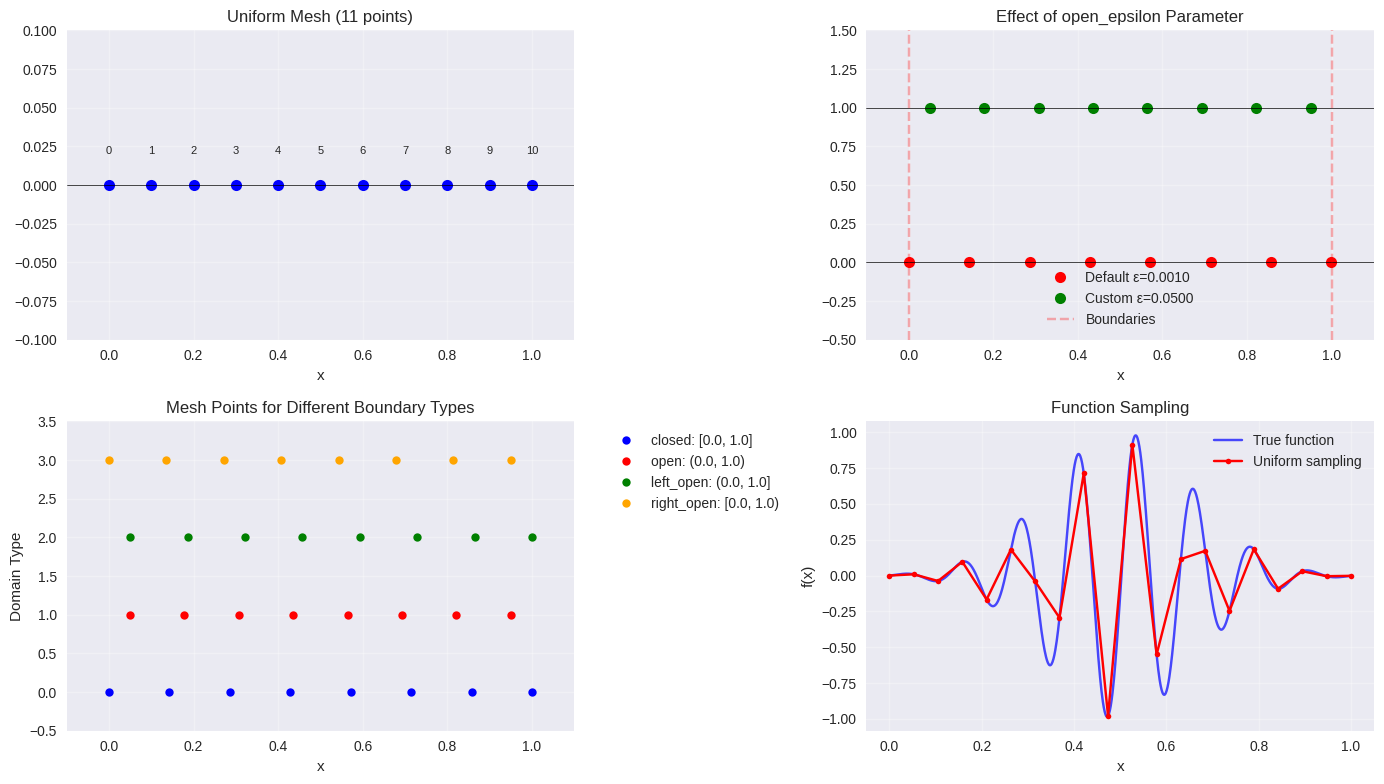

Uniform mesh: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [7]:
domain = IntervalDomain(0, 1, boundary_type='closed')

# Generate uniform mesh
n_points = 11
uniform_mesh = domain.uniform_mesh(n_points)

plt.figure(figsize=(14, 8))

# Uniform mesh
plt.subplot(2, 2, 1)
plt.plot(uniform_mesh, np.zeros_like(uniform_mesh), 'bo', markersize=8)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 0.1)
plt.xlabel('x')
plt.title(f'Uniform Mesh ({n_points} points)')
plt.grid(True, alpha=0.3)
for i, x in enumerate(uniform_mesh):
    plt.text(x, 0.02, f'{i}', ha='center', fontsize=8)

# Compare boundary behavior for different domain types
domain_types = ['closed', 'open', 'left_open', 'right_open']
colors = ['blue', 'red', 'green', 'orange']

plt.subplot(2, 2, 3)
for i, (bt, color) in enumerate(zip(domain_types, colors)):
    dom = IntervalDomain(0, 1, boundary_type=bt, open_epsilon=0.05)
    mesh = dom.uniform_mesh(8)
    plt.plot(mesh, np.full_like(mesh, i), 'o', color=color, markersize=6, label=f'{bt}: {dom}')

plt.ylim(-0.5, 3.5)
plt.xlim(-0.1, 1.1)
plt.xlabel('x')
plt.ylabel('Domain Type')
plt.title('Mesh Points for Different Boundary Types')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Demonstrate open_epsilon parameter
plt.subplot(2, 2, 2)
open_domain_default = IntervalDomain(0, 1, boundary_type='open')
open_domain_custom = IntervalDomain(0, 1, boundary_type='open', open_epsilon=0.05)

mesh_default = open_domain_default.uniform_mesh(8)
mesh_custom = open_domain_custom.uniform_mesh(8)

plt.plot(mesh_default, np.zeros_like(mesh_default), 'ro', markersize=8, label=f'Default ε={open_domain_default.open_epsilon:.4f}')
plt.plot(mesh_custom, np.ones_like(mesh_custom), 'go', markersize=8, label=f'Custom ε={open_domain_custom.open_epsilon:.4f}')
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(1, color='black', linewidth=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.3, label='Boundaries')
plt.axvline(1, color='red', linestyle='--', alpha=0.3)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.5, 1.5)
plt.xlabel('x')
plt.title('Effect of open_epsilon Parameter')
plt.legend()
plt.grid(True, alpha=0.3)

# Function sampling demonstration
plt.subplot(2, 2, 4)
def oscillatory_func(x):
    return np.exp(-20*(x-0.5)**2) * np.sin(50*x)

x_fine = np.linspace(0, 1, 1000)
y_fine = oscillatory_func(x_fine)
x_coarse = domain.uniform_mesh(20)
y_coarse = oscillatory_func(x_coarse)

plt.plot(x_fine, y_fine, 'b-', alpha=0.7, label='True function')
plt.plot(x_coarse, y_coarse, 'ro-', markersize=4, label='Uniform sampling')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function Sampling')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Uniform mesh: {uniform_mesh}")

### Detailed Examples and Visualization:

## 5. Integration Capabilities

Demonstrate various numerical integration methods and compare their accuracy.

Available methods:
- `'simpson'`: Simpson's rule (default)
- `'trapz'`: Trapezoidal rule
- `'adaptive'`: Scipy's adaptive quadrature

### Core API Usage:

In [8]:
# Core API: Integrate functions over the domain
domain = IntervalDomain(0, 1, boundary_type='closed')

# Simple integration with default Simpson's rule
result = domain.integrate(lambda x: x**2)

# Specify method and number of points
result = domain.integrate(lambda x: x**2, method='simpson', n_points=100)

# Different methods
result_trapz = domain.integrate(lambda x: x**2, method='trapz', n_points=100)
result_adaptive = domain.integrate(lambda x: x**2, method='adaptive')

In [9]:
domain = IntervalDomain(0, 1, boundary_type='closed')

# Define test functions with known integrals
test_functions = {
    'Polynomial: x²': (lambda x: x**2, 1/3),
    'Polynomial: x³': (lambda x: x**3, 1/4),
    'Exponential: eˣ': (lambda x: np.exp(x), np.e - 1),
    'Trigonometric: sin(πx)': (lambda x: np.sin(np.pi * x), 2/np.pi),
    'Oscillatory: sin(10πx)': (lambda x: np.sin(10*np.pi*x), 0.0)
}

integration_methods = ['simpson', 'trapz', 'adaptive']
method_params = {
    'simpson': {'n_points': 1000},
    'trapz': {'n_points': 1000},
    'adaptive': {}
}

print("Integration Method Comparison:")
print("="*80)
print(f"{'Function':25s} | {'Analytical':>12s} | {'Simpson':>12s} | {'Trapz':>12s} | {'Adaptive':>12s}")
print("-"*80)

for func_name, (func, analytical) in test_functions.items():
    results = [analytical]  # Start with analytical result

    for method in integration_methods:
        try:
            result = domain.integrate(func, method=method, **method_params[method])
            results.append(result)
        except Exception as e:
            results.append(float('nan'))

    print(f"{func_name:25s} | {results[0]:12.6f} | {results[1]:12.6f} | {results[2]:12.6f} | {results[3]:12.6f}")

# Error analysis
print("\nError Analysis (|numerical - analytical|):")
print("="*80)
print(f"{'Function':25s} | {'Simpson':>12s} | {'Trapz':>12s} | {'Adaptive':>12s}")
print("-"*80)

for func_name, (func, analytical) in test_functions.items():
    errors = []

    for method in integration_methods:
        try:
            result = domain.integrate(func, method=method, **method_params[method])
            error = abs(result - analytical)
            errors.append(error)
        except:
            errors.append(float('nan'))

    print(f"{func_name:25s} | {errors[0]:12.2e} | {errors[1]:12.2e} | {errors[2]:12.2e}")

Integration Method Comparison:
Function                  |   Analytical |      Simpson |        Trapz |     Adaptive
--------------------------------------------------------------------------------
Polynomial: x²            |     0.333333 |     0.333333 |     0.333334 |     0.333333
Polynomial: x³            |     0.250000 |     0.250000 |     0.250000 |     0.250000
Exponential: eˣ           |     1.718282 |     1.718282 |     1.718282 |     1.718282
Trigonometric: sin(πx)    |     0.636620 |     0.636620 |     0.636619 |     0.636620
Oscillatory: sin(10πx)    |     0.000000 |    -0.000000 |     0.000000 |    -0.000000

Error Analysis (|numerical - analytical|):
Function                  |      Simpson |        Trapz |     Adaptive
--------------------------------------------------------------------------------
Polynomial: x²            |     0.00e+00 |     1.67e-07 |     5.55e-17
Polynomial: x³            |     2.51e-13 |     2.51e-07 |     0.00e+00
Exponential: eˣ           |     1.

### Detailed Comparison and Analysis:

## 6. Integration over Multiple Support Regions

The `integrate` method can handle integration over multiple disjoint subintervals.

### Core API Usage:

In [10]:
# Core API: Integration over subdomains
domain = IntervalDomain(0, 2, boundary_type='closed')

# Full domain
result_full = domain.integrate(lambda x: x**2)

# Single subdomain using 'support' parameter
result_sub = domain.integrate(lambda x: x**2, support=(0.5, 1.5))

# Multiple disjoint regions (points automatically allocated proportionally)
result_multi = domain.integrate(lambda x: x**2, support=[(0.0, 0.5), (1.0, 1.5)])

Integration over full domain [0, 2]: 2.666667
Integration over subdomain [0.5, 1.5]: 1.083333
Integration over multiple regions [(0.0, 0.5), (1.0, 1.5)]: 0.833333


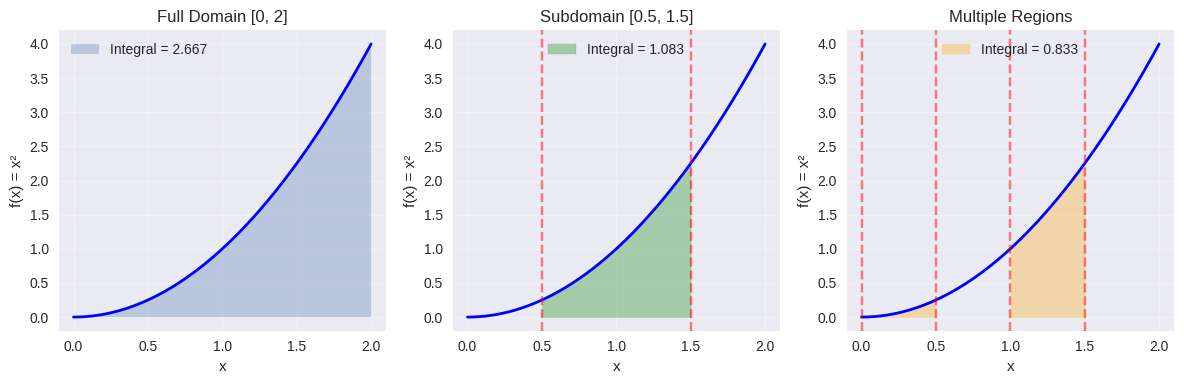

In [11]:
# Create a domain
domain = IntervalDomain(0, 2, boundary_type='closed')

# Define a function
def f(x):
    return x**2

# Single interval integration
result_full = domain.integrate(f, method='simpson', n_points=100)
print(f"Integration over full domain [0, 2]: {result_full:.6f}")

# Integration over a subdomain
result_sub = domain.integrate(f, method='simpson', support=(0.5, 1.5), n_points=100)
print(f"Integration over subdomain [0.5, 1.5]: {result_sub:.6f}")

# Integration over multiple disjoint regions
# Points are automatically allocated proportionally to region sizes
multiple_supports = [(0.0, 0.5), (1.0, 1.5)]
result_multi = domain.integrate(f, method='simpson', support=multiple_supports, n_points=100)
print(f"Integration over multiple regions {multiple_supports}: {result_multi:.6f}")

# Visualize
x_plot = np.linspace(0, 2, 1000)
y_plot = f(x_plot)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2)
plt.fill_between(x_plot, 0, y_plot, alpha=0.3, label=f'Integral = {result_full:.3f}')
plt.xlabel('x')
plt.ylabel('f(x) = x²')
plt.title('Full Domain [0, 2]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x_plot, y_plot, 'b-', linewidth=2)
mask = (x_plot >= 0.5) & (x_plot <= 1.5)
plt.fill_between(x_plot[mask], 0, y_plot[mask], alpha=0.3, color='green', label=f'Integral = {result_sub:.3f}')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(1.5, color='red', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x) = x²')
plt.title('Subdomain [0.5, 1.5]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(x_plot, y_plot, 'b-', linewidth=2)
mask1 = (x_plot >= 0.0) & (x_plot <= 0.5)
mask2 = (x_plot >= 1.0) & (x_plot <= 1.5)
plt.fill_between(x_plot[mask1], 0, y_plot[mask1], alpha=0.3, color='orange', label=f'Integral = {result_multi:.3f}')
plt.fill_between(x_plot[mask2], 0, y_plot[mask2], alpha=0.3, color='orange')
for (a, b) in multiple_supports:
    plt.axvline(a, color='red', linestyle='--', alpha=0.5)
    plt.axvline(b, color='red', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('f(x) = x²')
plt.title('Multiple Regions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization:

## 7. Domain Restrictions and Subintervals

Show how to create subdomains and their applications.

### Core API Usage:

In [12]:
# Core API: Create subdomains
original_domain = IntervalDomain(-2, 3, boundary_type='closed')

# Restrict to subinterval [a, b]
subdomain = original_domain.restriction_to_subinterval(-1, 1)

# Each subdomain inherits boundary type from parent
print(f"Subdomain: {subdomain}, length: {subdomain.length}")

Subdomain: [-1.0, 1.0], length: 2.0


Domain Restrictions:
Original domain: [-2.0, 3.0]
Restriction 1:   [-1.0, 1.0]
Restriction 2:   [0.0, 2.0]
Restriction 3:   [1.5, 2.5]


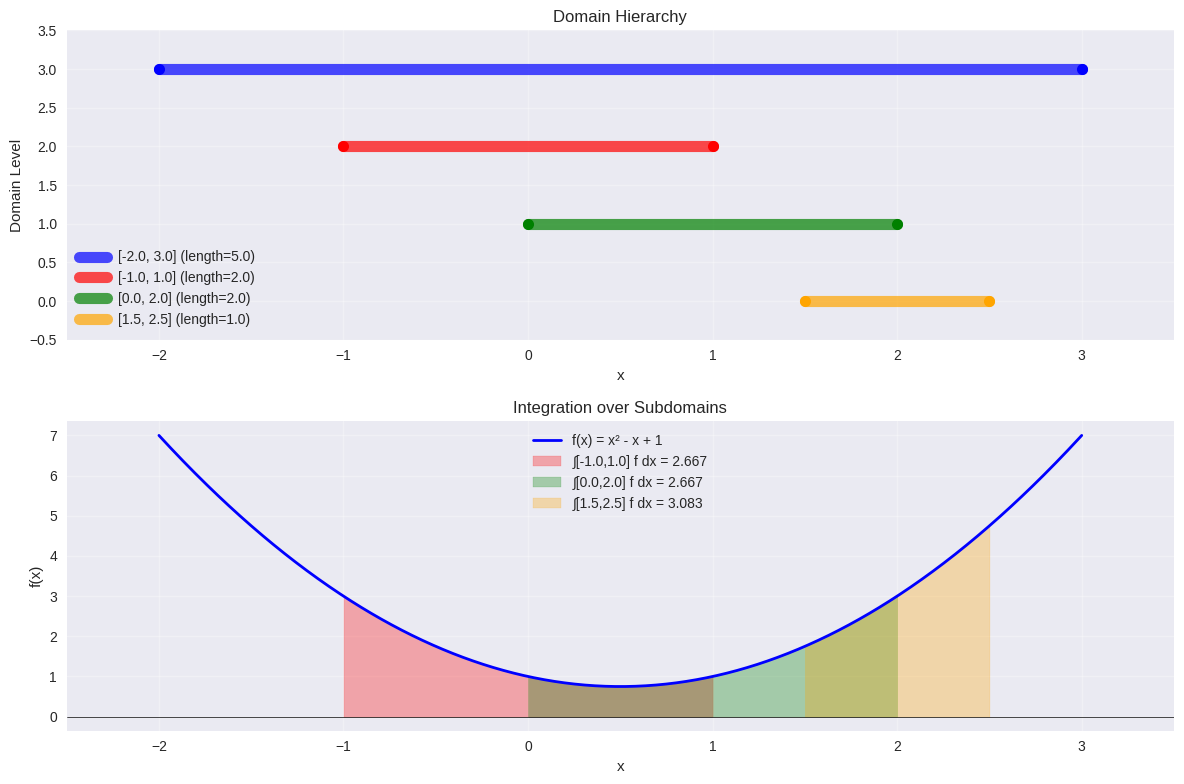


Integration Additivity Test (non-overlapping):
∫[-2,3] f dx = 14.166667
∫[-2,0] + ∫[0,1.5] + ∫[1.5,3] = 14.166667
Difference: 0.00e+00

Error Handling for Invalid Subintervals:
✓ Correctly caught error: Subinterval [5, 6] outside domain [-2.0, 3.0]


In [13]:
# Start with a larger domain
original_domain = IntervalDomain(-2, 3, boundary_type='closed', name="Original")

# Create various subintervals
sub1 = original_domain.restriction_to_subinterval(-1, 1)
sub2 = original_domain.restriction_to_subinterval(0, 2)
sub3 = original_domain.restriction_to_subinterval(1.5, 2.5)

print("Domain Restrictions:")
print("="*40)
print(f"Original domain: {original_domain}")
print(f"Restriction 1:   {sub1}")
print(f"Restriction 2:   {sub2}")
print(f"Restriction 3:   {sub3}")

# Visualize domain hierarchy
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Domain visualization
domains = [original_domain, sub1, sub2, sub3]
colors = ['blue', 'red', 'green', 'orange']
y_positions = [3, 2, 1, 0]

for domain, color, y in zip(domains, colors, y_positions):
    ax1.plot([domain.a, domain.b], [y, y], color=color, linewidth=8, alpha=0.7,
             label=f'{domain} (length={domain.length:.1f})')
    ax1.plot(domain.a, y, 'o', color=color, markersize=8)
    ax1.plot(domain.b, y, 'o', color=color, markersize=8)

ax1.set_xlim(-2.5, 3.5)
ax1.set_ylim(-0.5, 3.5)
ax1.set_xlabel('x')
ax1.set_ylabel('Domain Level')
ax1.set_title('Domain Hierarchy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Integration over subdomains
def test_func(x):
    return x**2 - x + 1

x_fine = np.linspace(-2, 3, 1000)
y_fine = test_func(x_fine)

ax2.plot(x_fine, y_fine, 'b-', linewidth=2, label='f(x) = x² - x + 1')

# Shade integration regions
for i, (domain, color) in enumerate(zip(domains[1:], colors[1:])):
    x_region = np.linspace(domain.a, domain.b, 100)
    y_region = test_func(x_region)
    integral_value = domain.integrate(test_func, method='simpson', n_points=100)

    ax2.fill_between(x_region, 0, y_region, alpha=0.3, color=color,
                    label=f'∫[{domain.a},{domain.b}] f dx = {integral_value:.3f}')

ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_xlim(-2.5, 3.5)
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Integration over Subdomains')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify additivity of integration for non-overlapping subdomains
# Create three non-overlapping subdomains
sub_a = original_domain.restriction_to_subinterval(-2, 0)
sub_b = original_domain.restriction_to_subinterval(0, 1.5)
sub_c = original_domain.restriction_to_subinterval(1.5, 3)

total_integral = original_domain.integrate(test_func, method='simpson', n_points=300)
sum_of_parts = (sub_a.integrate(test_func, method='simpson', n_points=100) +
                sub_b.integrate(test_func, method='simpson', n_points=100) +
                sub_c.integrate(test_func, method='simpson', n_points=100))

print("\nIntegration Additivity Test (non-overlapping):")
print(f"∫[-2,3] f dx = {total_integral:.6f}")
print(f"∫[-2,0] + ∫[0,1.5] + ∫[1.5,3] = {sum_of_parts:.6f}")
print(f"Difference: {abs(total_integral - sum_of_parts):.2e}")

# Test error handling
print("\nError Handling for Invalid Subintervals:")
try:
    bad_sub = original_domain.restriction_to_subinterval(5, 6)  # Outside original
except ValueError as e:
    print(f"✓ Correctly caught error: {e}")

### Detailed Examples and Visualization:

## 8. Splitting Domains at Discontinuities

The `split_at_discontinuities` method allows splitting a domain at specified points, useful for piecewise functions.

### Core API Usage:

In [14]:
# Core API: Split domain at discontinuity points
domain = IntervalDomain(0, 3, boundary_type='closed')

# Split at specified points (returns list of subdomains)
subdomains = domain.split_at_discontinuities([1.0, 2.0])

# Each subdomain has appropriate boundary types to avoid overlaps
for i, sub in enumerate(subdomains):
    print(f"Subdomain {i}: {sub}")

Subdomain 0: [0.0, 1.0)
Subdomain 1: (1.0, 2.0)
Subdomain 2: (2.0, 3.0]


Original domain: [0.0, 3.0]
Discontinuity points: [1.0, 2.0]

Subdomains created:
  Subdomain 0: [0.0, 1.0)
  Subdomain 1: (1.0, 2.0)
  Subdomain 2: (2.0, 3.0]

Integration over each subdomain:
  Subdomain 0 [0.0, 1.0): value=1, integral=1.000
  Subdomain 1 (1.0, 2.0): value=2, integral=2.000
  Subdomain 2 (2.0, 3.0]: value=3, integral=3.000

Total integral: 6.000


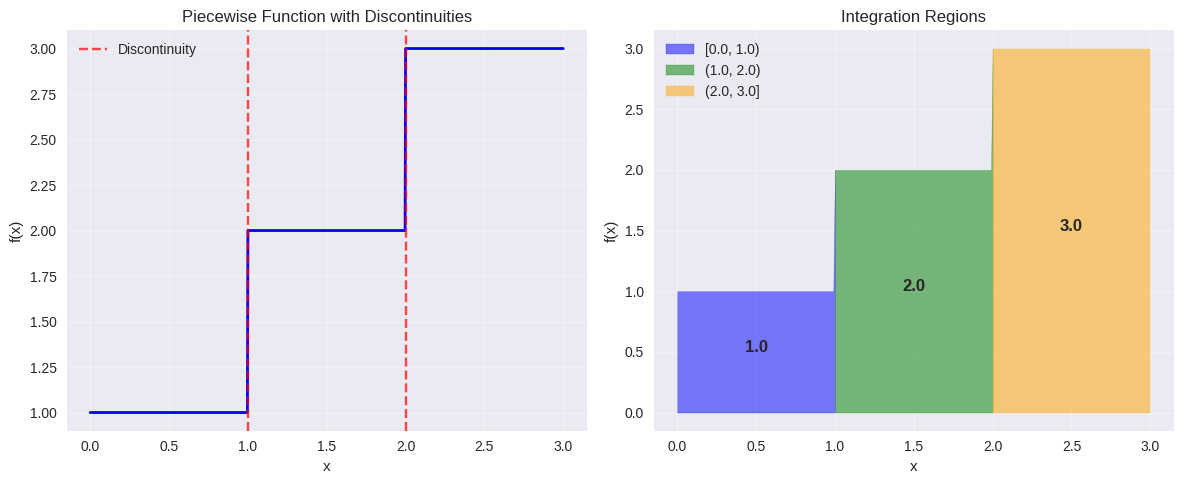

In [15]:
# Create a domain with discontinuities
domain = IntervalDomain(0, 3, boundary_type='closed')

# Split at discontinuity points
disc_points = [1.0, 2.0]
subdomains = domain.split_at_discontinuities(disc_points)

print(f"Original domain: {domain}")
print(f"Discontinuity points: {disc_points}")
print(f"\nSubdomains created:")
for i, sub in enumerate(subdomains):
    print(f"  Subdomain {i}: {sub}")

# Define a piecewise function with discontinuities
def piecewise_func(x):
    """Piecewise function: 1 on [0,1), 2 on [1,2), 3 on [2,3]"""
    return np.where(x < 1, 1, np.where(x < 2, 2, 3))

# Integrate over each subdomain
print("\nIntegration over each subdomain:")
total = 0
for i, sub in enumerate(subdomains):
    # For piecewise constant, we can evaluate at the center
    value = piecewise_func(np.array([sub.center]))[0]
    integral = value * sub.length
    total += integral
    print(f"  Subdomain {i} {sub}: value={value}, integral={integral:.3f}")

print(f"\nTotal integral: {total:.3f}")

# Visualize
x_plot = np.linspace(0, 3, 1000)
y_plot = piecewise_func(x_plot)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2)
for point in disc_points:
    plt.axvline(point, color='red', linestyle='--', alpha=0.7, label='Discontinuity' if point == disc_points[0] else '')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Piecewise Function with Discontinuities')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
colors = ['blue', 'green', 'orange']
for i, (sub, color) in enumerate(zip(subdomains, colors)):
    x_region = np.linspace(sub.a, sub.b, 100)
    y_region = piecewise_func(x_region)
    value = piecewise_func(np.array([sub.center]))[0]
    plt.fill_between(x_region, 0, y_region, alpha=0.5, color=color, label=f'{sub}')
    plt.text(sub.center, value/2, f'{value * sub.length:.1f}', ha='center', fontsize=12, weight='bold')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Integration Regions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Piecewise Function Example with Visualization:

## 9. Vectorized vs Non-Vectorized Functions

The integration methods can auto-detect whether functions are vectorized or not.

### Core API Usage:

In [16]:
# Core API: Auto-detection of vectorization
domain = IntervalDomain(0, 1, boundary_type='closed')

# Vectorized function (works on arrays) - auto-detected
result = domain.integrate(lambda x: np.sin(x) * np.exp(-x))

# Explicitly specify vectorization for best performance
result = domain.integrate(lambda x: np.sin(x) * np.exp(-x), vectorized=True)

# For scalar-only functions, set vectorized=False
def scalar_only_func(x):
    # Function that only works on single values
    return float(np.sin(x))

result = domain.integrate(scalar_only_func, vectorized=False)

In [17]:
import time

domain = IntervalDomain(0, 1, boundary_type='closed')

# Vectorized function
def vectorized_func(x):
    return np.sin(x) * np.exp(-x)

# Non-vectorized function (only works on scalars)
def scalar_func(x):
    if isinstance(x, np.ndarray):
        raise ValueError("This function only works on scalars")
    return np.sin(x) * np.exp(-x)

# Test auto-detection
print("Auto-detection of vectorization:")
result1 = domain.integrate(vectorized_func, method='simpson', n_points=100)
print(f"  Vectorized function result: {result1:.6f}")

result2 = domain.integrate(scalar_func, method='simpson', n_points=100, vectorized=False)
print(f"  Scalar function result: {result2:.6f}")

# Performance comparison
n_points = 1000

start = time.time()
result_vec = domain.integrate(vectorized_func, method='simpson', n_points=n_points, vectorized=True)
time_vec = time.time() - start

start = time.time()
result_scalar = domain.integrate(vectorized_func, method='simpson', n_points=n_points, vectorized=False)
time_scalar = time.time() - start

print(f"\nPerformance comparison (n={n_points}):")
print(f"  Vectorized:   {time_vec*1000:.2f} ms, result={result_vec:.6f}")
print(f"  Non-vectorized: {time_scalar*1000:.2f} ms, result={result_scalar:.6f}")
print(f"  Speedup: {time_scalar/time_vec:.1f}x")

Auto-detection of vectorization:
  Vectorized function result: 0.245837
  Scalar function result: 0.245837

Performance comparison (n=1000):
  Vectorized:   1.54 ms, result=0.245837
  Non-vectorized: 2.47 ms, result=0.245837
  Speedup: 1.6x


### Performance Comparison:

## 10. Summary

The `IntervalDomain` class from `intervalinf` provides:

1. **Flexible boundary types**: closed, open, left-open, right-open
2. **Topological operations**: interior, closure, boundary points
3. **Mesh generation**: uniform meshes respecting boundary types via `open_epsilon`
4. **Integration methods**: Simpson, trapezoidal, and adaptive quadrature
5. **Multi-region support**: Integration over multiple disjoint intervals
6. **Domain operations**: restrictions, splitting at discontinuities
7. **Vectorization support**: Automatic detection or manual specification

This provides a solid foundation for:
- Lebesgue and Sobolev space constructions
- FEM and spectral methods
- Bayesian inference with function-valued priors
- Any application requiring rigorous treatment of 1D domains